In [ ]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("GIE_API_KEY")
COUNTRY = "FR"

url = "https://agsi.gie.eu/api"
params = {
    "country": COUNTRY,
    "from": "2025-01-01",
    "size": 300
}
headers = {"x-key": API_KEY}

print(f"Fetching data for {COUNTRY}...")
response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    data = response.json()
    
    records = []
    for day in data['data']:
        records.append({
            'Date': day['gasDayStart'],
            'Stock_TWh': float(day['gasInStorage']),
            'Full_Pct': float(day['full'])
        })
    
    df = pd.DataFrame(records)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    print(df.tail())
    
    df.plot(x='Date', y='Full_Pct', title=f"Gas Stock {COUNTRY} (%)", figsize=(10, 5))
    plt.show()

else:
    print(f"Error: {response.status_code}")

In [1]:
import os
import time
from datetime import date

import pandas as pd
import requests
from dotenv import load_dotenv

# --- Configuration ---
COUNTRIES = ["FR", "DE", "IT", "NL", "BE"]
DATE_FROM = "2016-01-01"
DATE_TO = date.today().isoformat()
URL = "https://agsi.gie.eu/api"
PAGE_SIZE = 300
PAGE_SLEEP_SECONDS = 0.35
COUNTRY_SLEEP_SECONDS = 1.0
REQUEST_TIMEOUT = (10, 60)  # (connect timeout, read timeout)
MAX_RETRIES = 8
BACKOFF_BASE_SECONDS = 1.8

load_dotenv()
API_KEY = os.getenv("GIE_API_KEY")
if not API_KEY:
    raise ValueError("Missing GIE_API_KEY. Add it to your .env file.")

HEADERS = {"x-key": API_KEY}
session = requests.Session()
session.headers.update(HEADERS)


def _retry_sleep(attempt: int, floor: float = 1.0, cap: float = 60.0) -> float:
    delay = max(floor, min(cap, BACKOFF_BASE_SECONDS ** attempt))
    time.sleep(delay)
    return delay


def _request_page(country_code: str, page: int):
    """Request one page with retry logic for rate limits and transient network/server issues."""
    params = {
        "country": country_code,
        "from": DATE_FROM,
        "to": DATE_TO,
        "size": PAGE_SIZE,
        "page": page,
    }

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = session.get(URL, params=params, timeout=REQUEST_TIMEOUT)
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectTimeout, requests.exceptions.ConnectionError) as exc:
            delay = _retry_sleep(attempt)
            print(f"  [retry] {country_code} page {page} network timeout/error ({exc.__class__.__name__}), retry in {delay:.1f}s")
            continue

        if response.status_code == 429:
            retry_after = response.headers.get("Retry-After")
            if retry_after and retry_after.isdigit():
                wait = float(retry_after)
            else:
                wait = min(60.0, 2.0 * attempt)
            time.sleep(wait)
            print(f"  [retry] {country_code} page {page} rate-limited (429), retry in {wait:.1f}s")
            continue

        if 500 <= response.status_code < 600:
            delay = _retry_sleep(attempt)
            print(f"  [retry] {country_code} page {page} server error {response.status_code}, retry in {delay:.1f}s")
            continue

        response.raise_for_status()
        payload = response.json()
        return payload.get("data", [])

    raise RuntimeError(f"Failed after retries for country={country_code}, page={page}")


def fetch_country_history(country_code: str):
    """Fetch full history for one country with pagination until empty or duplicate pages."""
    page = 1
    seen_dates = set()
    records = []

    while True:
        rows = _request_page(country_code, page)

        # Stop when API returns no rows
        if not rows:
            break

        new_rows = 0
        for row in rows:
            gas_day = row.get("gasDayStart")
            if not gas_day or gas_day in seen_dates:
                continue

            seen_dates.add(gas_day)
            records.append(
                {
                    "date": gas_day,
                    "country": country_code,
                    "gasInStorage": row.get("gasInStorage"),
                    "full": row.get("full"),
                }
            )
            new_rows += 1

        # Stop if API keeps returning duplicates and no unseen records
        if new_rows == 0:
            break

        page += 1
        time.sleep(PAGE_SLEEP_SECONDS)

    return records


# --- Extraction ---
all_records = []
for i, country in enumerate(COUNTRIES, start=1):
    print(f"Fetching {country} ({i}/{len(COUNTRIES)})...")
    country_records = fetch_country_history(country)
    print(f"  rows: {len(country_records)}")
    all_records.extend(country_records)

    # Small cooldown between countries to reduce transient failures/rate-limit bursts.
    if i < len(COUNTRIES):
        time.sleep(COUNTRY_SLEEP_SECONDS)


# --- Data processing ---
df = pd.DataFrame(all_records)

if df.empty:
    print("Total rows fetched: 0")
else:
    # Enforce requested dtypes on raw columns.
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    for col in ["gasInStorage", "full"]:
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

    df["country"] = df["country"].astype("string")

    # Rename to final schema.
    df = df.rename(
        columns={
            "gasInStorage": "storage_twh",
            "full": "fill_pct",
        }
    )

    # Sort final DataFrame.
    df = df.sort_values(["country", "date"]).reset_index(drop=True)

    # --- Storage ---
    output_path = os.path.join("..", "data", "raw", "gie_history_raw.csv")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)

    # --- Summary ---
    print(f"Total rows fetched: {len(df)}")
    summary = df.groupby("country")["date"].agg(["min", "max"]).reset_index()
    print(summary.to_string(index=False))



Fetching FR (1/5)...
  rows: 3693
Fetching DE (2/5)...
  rows: 3693
Fetching IT (3/5)...
  rows: 3694
Fetching NL (4/5)...
  rows: 3694
Fetching BE (5/5)...
  rows: 3694
Total rows fetched: 18468
country        min        max
     BE 2016-01-01 2026-02-10
     DE 2016-01-01 2026-02-09
     FR 2016-01-01 2026-02-09
     IT 2016-01-01 2026-02-10
     NL 2016-01-01 2026-02-10


## Exploration des donnees AGSI

Ces cellules servent a verifier la qualite des donnees et a visualiser les dynamiques par pays.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/raw/gie_history_raw.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Fichier introuvable: {DATA_PATH.resolve()}")

# Chargement et typage explicite
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["country"] = df["country"].astype("string")
df["storage_twh"] = pd.to_numeric(df["storage_twh"], errors="coerce")
df["fill_pct"] = pd.to_numeric(df["fill_pct"], errors="coerce")
df = df.sort_values(["country", "date"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Countries: {sorted(df['country'].dropna().unique())}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")

print("\nDtypes:")
print(df.dtypes)

display(df.head(5))
display(df.tail(5))


Rows: 18,468
Countries: ['BE', 'DE', 'FR', 'IT', 'NL']
Date range: 2016-01-01 -> 2026-02-10

Dtypes:
date           datetime64[us]
country                string
storage_twh           float64
fill_pct              float64
dtype: object


,date,country,storage_twh,fill_pct
0,2016-01-01,BE,5.0153,57.46
1,2016-01-02,BE,5.0028,57.26
2,2016-01-03,BE,5.0408,57.08
3,2016-01-04,BE,4.9827,56.23
4,2016-01-05,BE,4.9470,55.84


,date,country,storage_twh,fill_pct
18463,2026-02-06,NL,30.0971,20.86
18464,2026-02-07,NL,29.2869,20.30
18465,2026-02-08,NL,28.3398,19.64
18466,2026-02-09,NL,27.2201,18.86
18467,2026-02-10,NL,26.1093,18.09


### 1) Qualite des donnees

Controle des valeurs manquantes, doublons, valeurs hors bornes et trous temporels.


Doublons (country, date): 0
fill_pct hors [0, 100]: 140
storage_twh negatif: 0

Valeurs manquantes par colonne:
date           0
country        0
storage_twh    0
fill_pct       0


,country,rows,min_date,max_date,expected_days,observed_days,missing_dates,coverage_pct,longest_gap_days
0,BE,3694,2016-01-01,2026-02-10,3694,3694,0,100.0,0
1,DE,3693,2016-01-01,2026-02-09,3693,3693,0,100.0,0
2,FR,3693,2016-01-01,2026-02-09,3693,3693,0,100.0,0
3,IT,3694,2016-01-01,2026-02-10,3694,3694,0,100.0,0
4,NL,3694,2016-01-01,2026-02-10,3694,3694,0,100.0,0


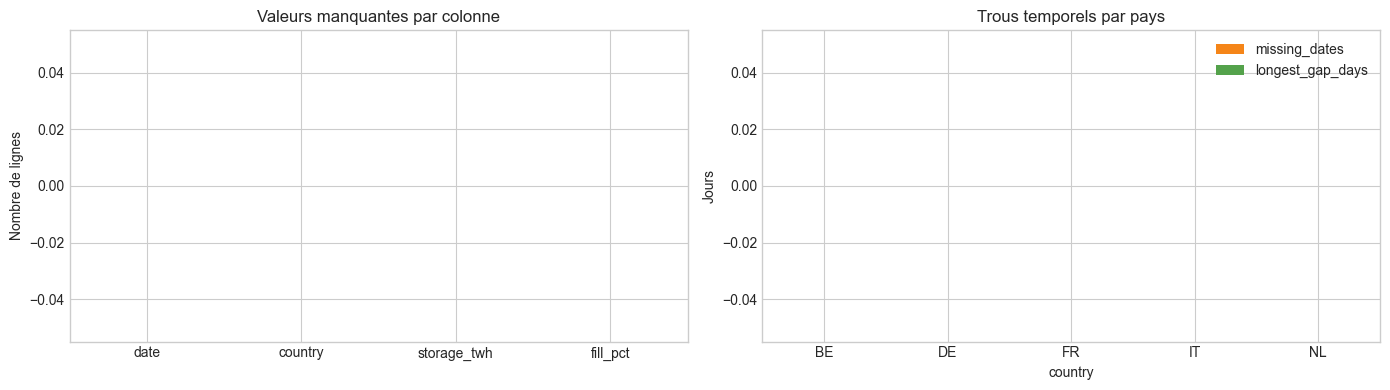

In [3]:
# Diagnostics globaux
missing_by_col = df.isna().sum().rename("missing_values")
duplicate_country_date = df.duplicated(subset=["country", "date"]).sum()
invalid_fill = ((df["fill_pct"] < 0) | (df["fill_pct"] > 100)).sum()
invalid_storage = (df["storage_twh"] < 0).sum()

print(f"Doublons (country, date): {duplicate_country_date}")
print(f"fill_pct hors [0, 100]: {int(invalid_fill)}")
print(f"storage_twh negatif: {int(invalid_storage)}")

print("\nValeurs manquantes par colonne:")
print(missing_by_col.to_string())

# Couverture journaliere par pays
quality_rows = []
for country, g in df.groupby("country", dropna=False):
    g = g.sort_values("date")
    observed = g["date"].dropna().dt.normalize()

    if observed.empty:
        quality_rows.append({
            "country": country,
            "rows": len(g),
            "min_date": pd.NaT,
            "max_date": pd.NaT,
            "expected_days": 0,
            "observed_days": 0,
            "missing_dates": 0,
            "coverage_pct": np.nan,
            "longest_gap_days": 0,
        })
        continue

    min_date, max_date = observed.min(), observed.max()
    expected = pd.date_range(min_date, max_date, freq="D")
    observed_idx = pd.DatetimeIndex(observed.unique()).sort_values()

    coverage = expected.isin(observed_idx).astype(int)
    missing_dates = int((coverage == 0).sum())

    longest_gap = 0
    current_gap = 0
    for is_present in coverage:
        if is_present == 0:
            current_gap += 1
            longest_gap = max(longest_gap, current_gap)
        else:
            current_gap = 0

    quality_rows.append({
        "country": country,
        "rows": len(g),
        "min_date": min_date.date(),
        "max_date": max_date.date(),
        "expected_days": len(expected),
        "observed_days": len(observed_idx),
        "missing_dates": missing_dates,
        "coverage_pct": round((len(observed_idx) / len(expected)) * 100, 2),
        "longest_gap_days": int(longest_gap),
    })

quality_df = pd.DataFrame(quality_rows).sort_values("country")
display(quality_df)

# Graphiques qualite
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

missing_by_col.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Valeurs manquantes par colonne")
axes[0].set_ylabel("Nombre de lignes")
axes[0].tick_params(axis="x", rotation=0)

quality_df_plot = quality_df.set_index("country")[["missing_dates", "longest_gap_days"]]
quality_df_plot.plot(kind="bar", ax=axes[1], color=["#F58518", "#54A24B"])
axes[1].set_title("Trous temporels par pays")
axes[1].set_ylabel("Jours")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### 2) Evolution temporelle

Visualisation de l'evolution du stock et du taux de remplissage.


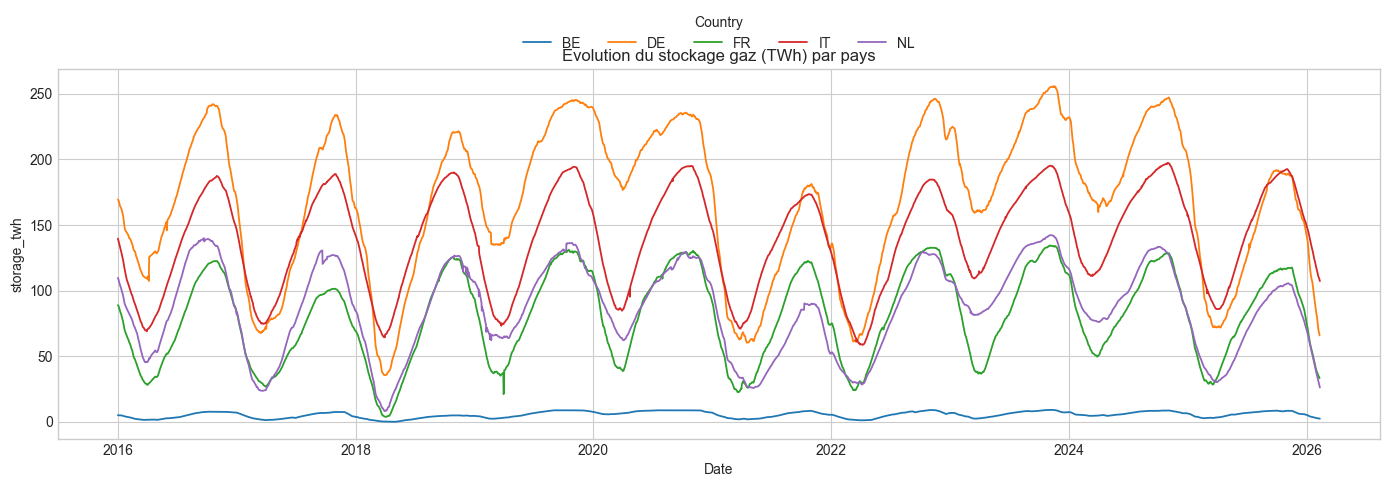

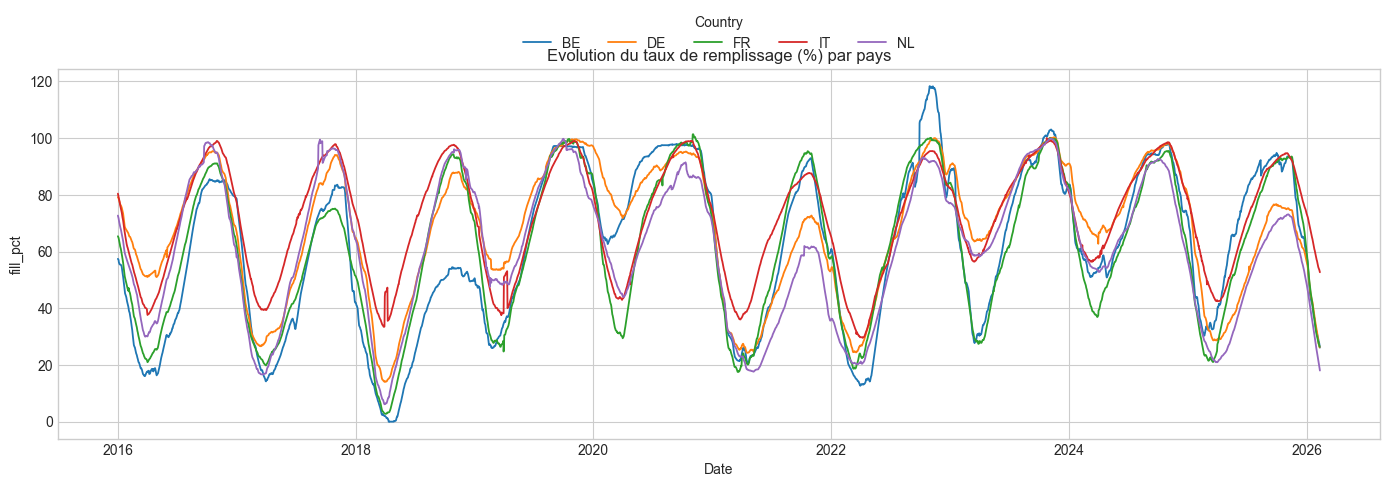

In [4]:
countries = sorted(df["country"].dropna().unique())

# Stock (TWh)
fig, ax = plt.subplots(figsize=(14, 5))
for country in countries:
    g = df[df["country"] == country]
    ax.plot(g["date"], g["storage_twh"], label=country, linewidth=1.3)

ax.set_title("Evolution du stockage gaz (TWh) par pays")
ax.set_xlabel("Date")
ax.set_ylabel("storage_twh")
ax.legend(title="Country", ncol=len(countries), loc="upper center", bbox_to_anchor=(0.5, 1.18))
plt.tight_layout()
plt.show()

# Fill (%)
fig, ax = plt.subplots(figsize=(14, 5))
for country in countries:
    g = df[df["country"] == country]
    ax.plot(g["date"], g["fill_pct"], label=country, linewidth=1.3)

ax.set_title("Evolution du taux de remplissage (%) par pays")
ax.set_xlabel("Date")
ax.set_ylabel("fill_pct")
ax.legend(title="Country", ncol=len(countries), loc="upper center", bbox_to_anchor=(0.5, 1.18))
plt.tight_layout()
plt.show()


### 3) Tendances lissees et saisonnalite

Moyenne glissante 30 jours et profil moyen mensuel.


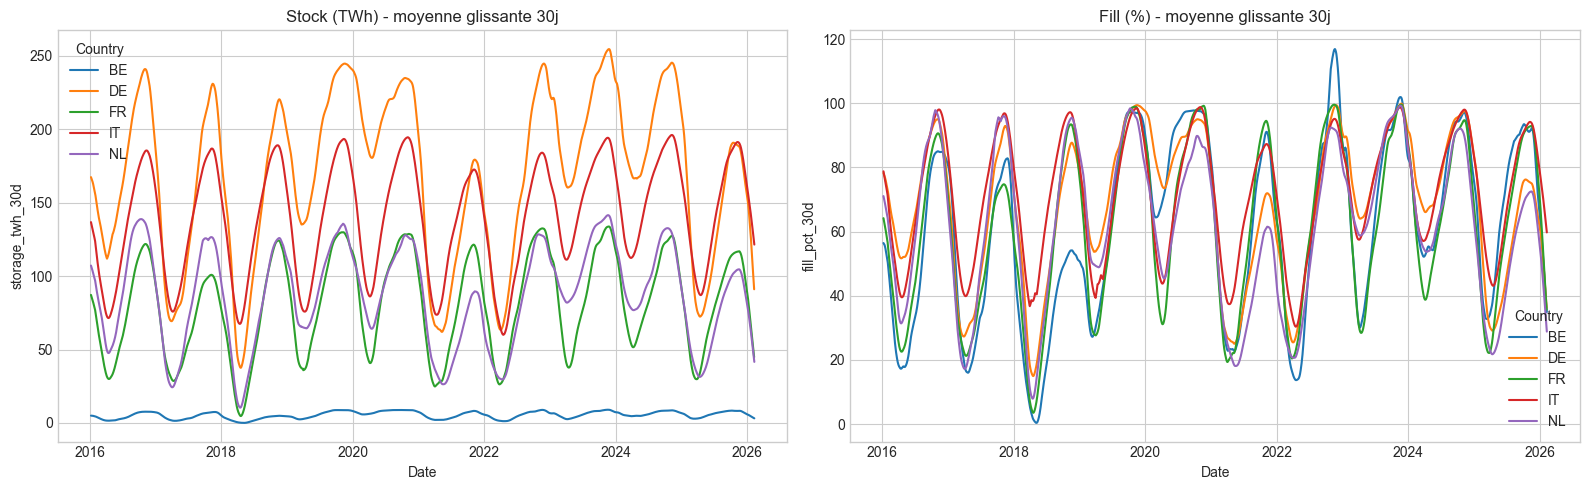

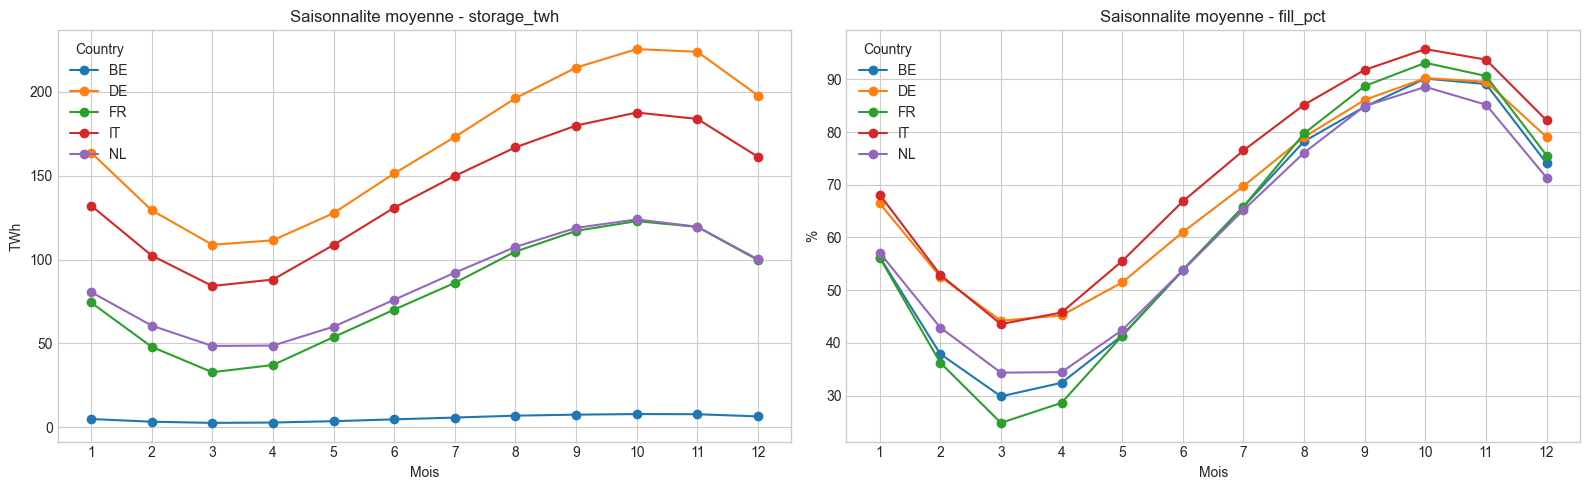

In [5]:
df_smooth = df.copy()
df_smooth["storage_twh_30d"] = (
    df_smooth.groupby("country", dropna=False)["storage_twh"]
    .transform(lambda s: s.rolling(30, min_periods=7).mean())
)
df_smooth["fill_pct_30d"] = (
    df_smooth.groupby("country", dropna=False)["fill_pct"]
    .transform(lambda s: s.rolling(30, min_periods=7).mean())
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for country in sorted(df_smooth["country"].dropna().unique()):
    g = df_smooth[df_smooth["country"] == country]
    axes[0].plot(g["date"], g["storage_twh_30d"], label=country, linewidth=1.5)
    axes[1].plot(g["date"], g["fill_pct_30d"], label=country, linewidth=1.5)

axes[0].set_title("Stock (TWh) - moyenne glissante 30j")
axes[0].set_ylabel("storage_twh_30d")
axes[1].set_title("Fill (%) - moyenne glissante 30j")
axes[1].set_ylabel("fill_pct_30d")
for ax in axes:
    ax.set_xlabel("Date")
    ax.legend(title="Country")

plt.tight_layout()
plt.show()

# Saisonnalite moyenne mensuelle
monthly = (
    df.assign(month=df["date"].dt.month)
    .groupby(["country", "month"], as_index=False)
    .agg(avg_fill_pct=("fill_pct", "mean"), avg_storage_twh=("storage_twh", "mean"))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for country in sorted(monthly["country"].dropna().unique()):
    g = monthly[monthly["country"] == country]
    axes[0].plot(g["month"], g["avg_storage_twh"], marker="o", label=country)
    axes[1].plot(g["month"], g["avg_fill_pct"], marker="o", label=country)

for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Mois")
    ax.legend(title="Country")

axes[0].set_title("Saisonnalite moyenne - storage_twh")
axes[0].set_ylabel("TWh")
axes[1].set_title("Saisonnalite moyenne - fill_pct")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()


### 4) Snapshot recent

Comparaison des dernieres valeurs disponibles par pays.


,country,date,storage_twh,fill_pct
3693,BE,2026-02-10,2.3514,26.18
7386,DE,2026-02-09,65.8645,26.23
11079,FR,2026-02-09,33.2573,26.45
14773,IT,2026-02-10,107.2367,52.74
18467,NL,2026-02-10,26.1093,18.09


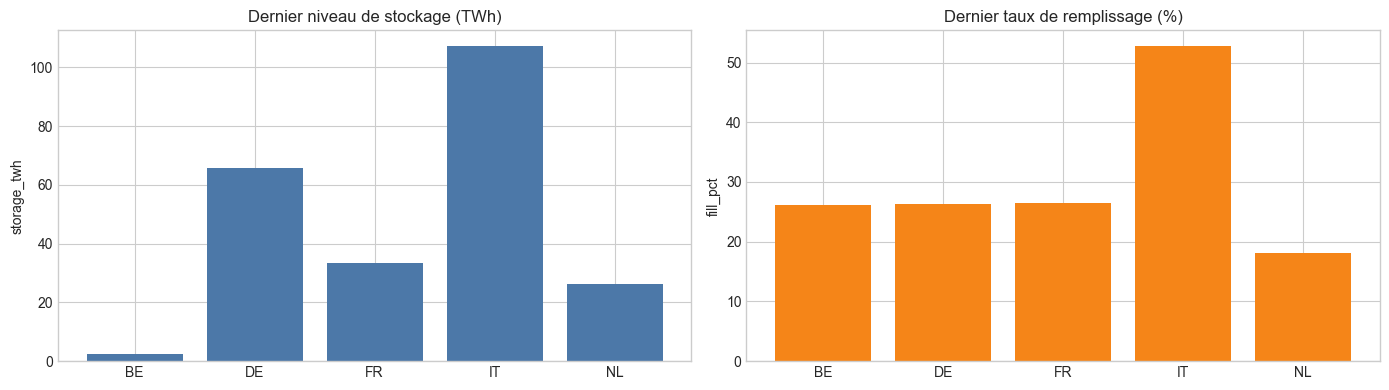

In [6]:
latest_per_country = (
    df.sort_values("date")
    .groupby("country", as_index=False)
    .tail(1)
    .sort_values("country")
)

display(latest_per_country[["country", "date", "storage_twh", "fill_pct"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(latest_per_country["country"], latest_per_country["storage_twh"], color="#4C78A8")
axes[0].set_title("Dernier niveau de stockage (TWh)")
axes[0].set_ylabel("storage_twh")

axes[1].bar(latest_per_country["country"], latest_per_country["fill_pct"], color="#F58518")
axes[1].set_title("Dernier taux de remplissage (%)")
axes[1].set_ylabel("fill_pct")

plt.tight_layout()
plt.show()
